In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [43]:
df = pd.read_csv('/content/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


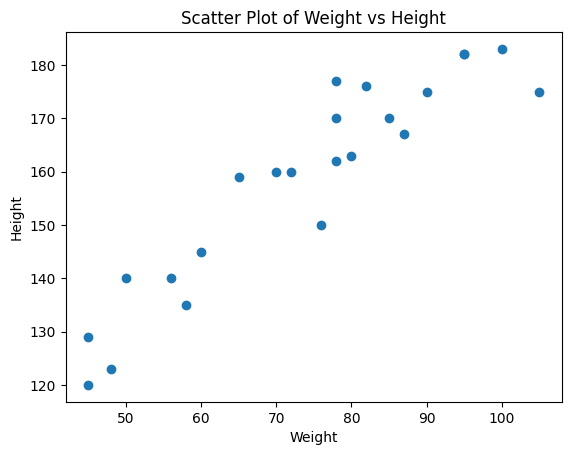

In [44]:
## Visualizing
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Scatter Plot of Weight vs Height')
plt.show()

In [45]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


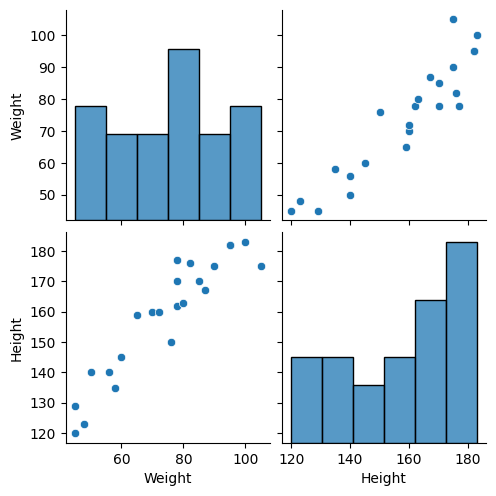

In [46]:
sns.pairplot(df)

In [47]:
## Dividing the Dataset
x = df[['Weight']]
y = df['Height']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [48]:
## Shape of our data
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (18, 1)
Shape of x_test: (5, 1)
Shape of y_train: (18,)
Shape of y_test: (5,)


In [49]:
np.round(x_train.describe(), 2)

,Weight
count,18.00
mean,74.28
std,18.20
min,45.00
25%,58.50
50%,77.00
75%,86.50
max,105.00


In [50]:
## Scaling the Data
scaler = StandardScaler()

x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

x_train_new = pd.DataFrame(x_train_sc, columns=x_train.columns)
x_test_new = pd.DataFrame(x_test_sc, columns=x_test.columns)

In [51]:
np.round(x_test_new.describe(),2)

,Weight
count,5.00
mean,-0.12
std,1.05
min,-1.66
25%,-0.52
50%,0.21
75%,0.21
max,1.17


Text(0, 0.5, 'Height')

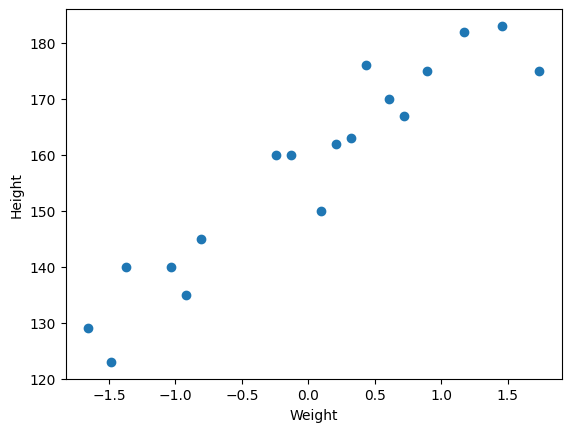

In [52]:
plt.scatter(x_train_new, y_train)
plt.xlabel('Weight')
plt.ylabel('Height')

In [53]:
model = LinearRegression(n_jobs=-1)
model.fit(x_train_new, y_train)

LinearRegression(n_jobs=-1)

In [54]:
## Slope and Intercept
print(f"Slope : {model.coef_}")
print(f"Intercept: {model.intercept_}")

Slope : [17.03440872]
Intercept: 157.5


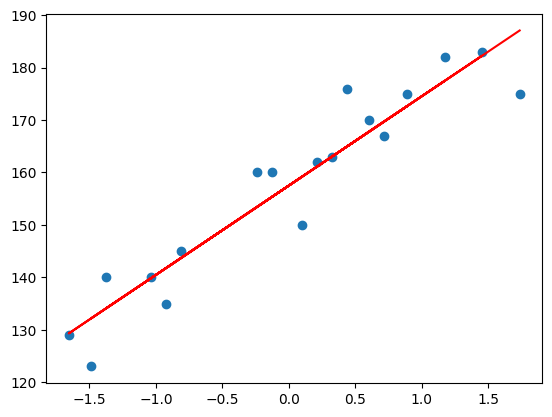

In [55]:
plt.scatter(x_train_new, y_train)
plt.plot(x_train_new, model.predict(x_train_new), color='red')

In [56]:
y_pred = model.predict(x_test_sc)
accuracy = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Accuracy of the model: {accuracy}")
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

Accuracy of the model: 0.776986986042344
Mean Squared Error: 109.77592599051664
Mean Absolute Error: 9.822657814519232
Root Mean Squared Error: 10.477400726827081
